In [231]:
# Работа с данными
import pandas as pd
import numpy as np

# Визуализации
import matplotlib.pyplot as plt
import plotly.express as px

# Тесты на стационарность
from statsmodels.tsa.stattools import adfuller, kpss

# Тест на автокорреляцию
from statsmodels.stats.diagnostic import acorr_ljungbox

# Анализ автокорреляции
from statsmodels.tsa.stattools import acf, pacf
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# Модели ARMA
from statsmodels.tsa.arima_process import ArmaProcess
from statsmodels.tsa.arima.model import ARIMA

# Декомпозиция
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.seasonal import STL, MSTL

from sklearn.metrics import mean_absolute_error, mean_squared_error

import warnings
warnings.filterwarnings("ignore")



import plotly.graph_objects as go

In [232]:
!pip install pmdarima

# auto ARIMA
import pmdarima as pm
from pmdarima import auto_arima

In [233]:
def adf_test(timeseries, maxlag=None):
    print("Results of Dickey-Fuller Test:")
    dftest = adfuller(timeseries, autolag="AIC", maxlag=maxlag)
    dfoutput = pd.Series(
        dftest[0:4],
        index=[
            "Test Statistic",
            "p-value",
            "# Lags Used",
            "Number of Observations Used",
        ],
    )
    for key, value in dftest[4].items():
        dfoutput["Critical Value (%s)" % key] = value
    print(dfoutput)

In [234]:
def kpss_test(timeseries):
    print("Results of KPSS Test:")
    kpsstest = kpss(timeseries, regression="c", nlags="auto")
    kpss_output = pd.Series(
        kpsstest[0:3], index=["Test Statistic", "p-value", "Lags Used"]
    )
    for key, value in kpsstest[3].items():
        kpss_output["Critical Value (%s)" % key] = value
    print(kpss_output)

In [235]:
def metrics(y_true, y_pred):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    print(f"RMSE: {rmse:.2f}")
    print(f"MAPE: {mape:.2f}%")
    return  float(round(rmse, 2)), float(round(mape, 2))

Первый временной ряд это цена акций Bitcoin к USDT за 7 лет

In [236]:
df = pd.read_csv('btc_usdt_7years_okx.csv')
df.head(15)

,timestamp,open,high,low,close,volume,datetime
0,1543190400000,4086.4,4200.0,3697.3,3864.0,24544.373605,2018-11-26
1,1543276800000,3864.0,3940.0,3681.9,3878.2,20157.433365,2018-11-27
2,1543363200000,3878.8,4398.0,3875.7,4263.3,21051.096753,2018-11-28
3,1543449600000,4259.7,4444.0,4130.0,4293.3,18704.026002,2018-11-29
4,1543536000000,4295.5,4337.9,3940.0,4039.0,20783.628787,2018-11-30
5,1543622400000,4040.6,4288.0,3958.5,4192.8,16060.595071,2018-12-01
6,1543708800000,4192.8,4310.4,4101.0,4160.6,15201.499766,2018-12-02
7,1543795200000,4160.6,4179.1,3821.0,3885.5,16949.218206,2018-12-03
8,1543881600000,3883.1,4089.9,3770.4,3951.1,17112.355226,2018-12-04
9,1543968000000,3951.1,3969.4,3740.0,3767.5,15236.658962,2018-12-05


In [237]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2555 entries, 0 to 2554
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   timestamp  2555 non-null   int64  
 1   open       2555 non-null   float64
 2   high       2555 non-null   float64
 3   low        2555 non-null   float64
 4   close      2555 non-null   float64
 5   volume     2555 non-null   float64
 6   datetime   2555 non-null   object 
dtypes: float64(5), int64(1), object(1)
memory usage: 139.9+ KB


In [238]:
df.shape

(2555, 7)

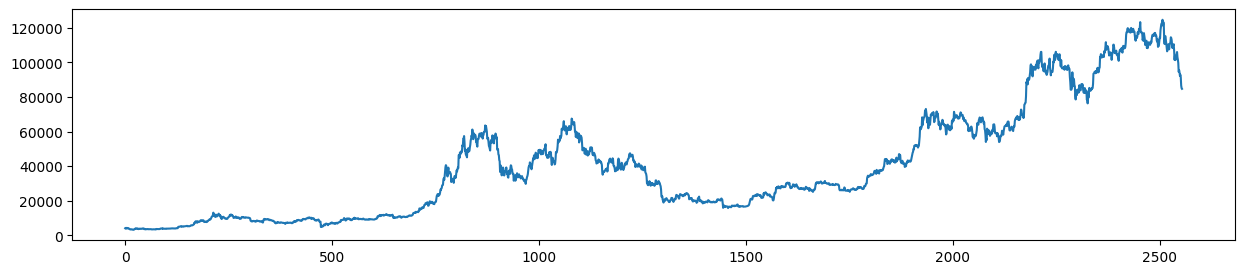

In [239]:
df["open"].plot(figsize=(15, 3))
plt.show()

In [240]:
df['datetime'] = pd.to_datetime(df['datetime'])
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2555 entries, 0 to 2554
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   timestamp  2555 non-null   int64         
 1   open       2555 non-null   float64       
 2   high       2555 non-null   float64       
 3   low        2555 non-null   float64       
 4   close      2555 non-null   float64       
 5   volume     2555 non-null   float64       
 6   datetime   2555 non-null   datetime64[ns]
dtypes: datetime64[ns](1), float64(5), int64(1)
memory usage: 139.9 KB


In [241]:
df.rename(columns={'datetime':'ds', 'open':'y'}, inplace=True)
df['y'] = df['y'].astype(float)
df = df[['ds', 'y']].sort_values(by='ds').set_index('ds')

df

,y
ds,
2018-11-26,4086.4
2018-11-27,3864.0
2018-11-28,3878.8
2018-11-29,4259.7
2018-11-30,4295.5
...,...
2025-11-19,92967.1
2025-11-20,91561.0
2025-11-21,86638.0


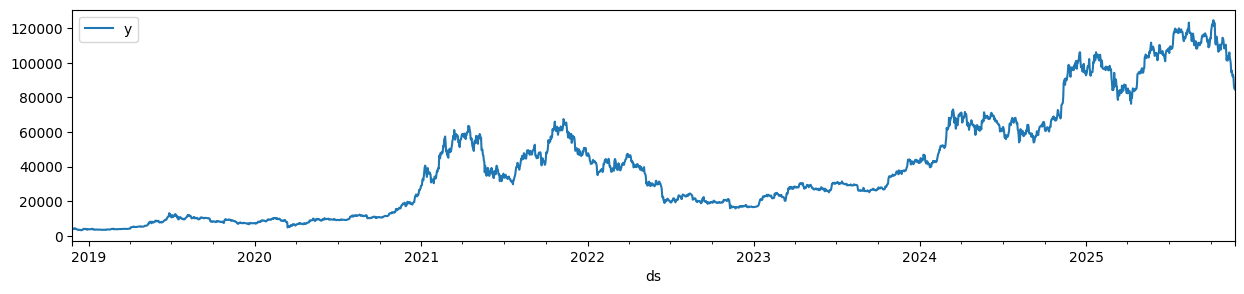

In [242]:
df.plot(figsize=(15, 3))
plt.show()

Как видим из графика нашего временного ряда, он не стационарен и визуально  имеет тренд примерно с 2023 года. Проверим наш временной ряд на стационарность с помощью ADF и KPSS тестов

In [243]:
adf_test(df['y'])

Results of Dickey-Fuller Test:
Test Statistic                   -0.879416
p-value                           0.794675
# Lags Used                       1.000000
Number of Observations Used    2553.000000
Critical Value (1%)              -3.432914
Critical Value (5%)              -2.862673
Critical Value (10%)             -2.567373
dtype: float64


ADF тест показывает , что ряд нестационарен так как p-value >0.05 , а значит мы не отказывемся от нулевой гипотезы

In [244]:
kpss_test(df['y'])

Results of KPSS Test:
Test Statistic            5.601893
p-value                   0.010000
Lags Used                30.000000
Critical Value (10%)      0.347000
Critical Value (5%)       0.463000
Critical Value (2.5%)     0.574000
Critical Value (1%)       0.739000
dtype: float64


KPSS тест показывает , что ряд нестационарен так как p-value <0.05 , а значит мы  отказывемся от нулевой гипотезы о стационарности, и говорим , что ряд не стационарен.

Проверим автокорреляцию с помощью ACF и PACF функций

In [245]:
acf_values = acf(df, nlags=20)

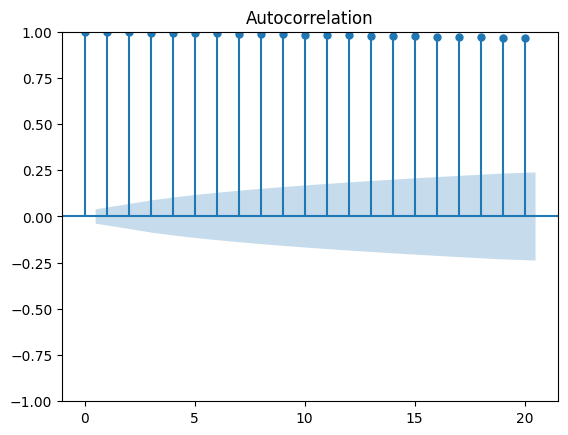

In [246]:
plot_acf(np.array(df), lags =20)
plt.show()

Как видим из ACF она очень медленно убывает, то есть коэффициенты автокорреляции до 20 лага остаются очень высокими близкими к 1 и еще и значимые , что говорит о не стационарности

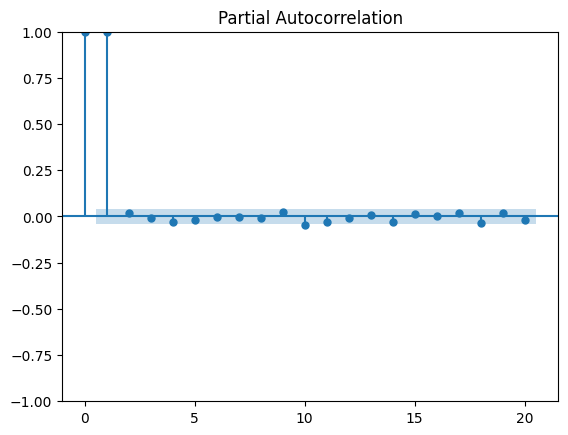

In [247]:
pacf_values = pacf(df, nlags=20)
plot_pacf(np.array(df), lags = 20)
plt.show()

PACF показывает один значимый лаг, остальные входят в доверительный интервал

Так же проверим автокорреляцию тестом Льюнга Бокса

In [248]:
acorr_ljungbox(df, return_df=True)

,lb_stat,lb_pvalue
1,2550.135226,0.0
2,5093.746930,0.0
3,7630.689407,0.0
4,10160.481963,0.0
5,12682.848474,0.0
6,15197.799062,0.0
7,17705.290578,0.0
8,20205.179522,0.0
9,22697.865922,0.0
10,25182.624323,0.0


Как видим из теста, ряд автокоррелирован до 10 лага

Оба теста ADF KPSS показали что ряд не стационарен. Для того что бы применить модель ARMA надо привести его стационарному виду. Применим дифференцирование для того что бы убрать тренд и сезоность и сделать ряд стационарным

In [249]:
df['diff'] = df['y'].diff()
df.head()

,y,diff
ds,,
2018-11-26,4086.4,NaN
2018-11-27,3864.0,-222.4
2018-11-28,3878.8,14.8
2018-11-29,4259.7,380.9
2018-11-30,4295.5,35.8


In [250]:
fig = px.line(df, x=df.index, y=df['diff'],
              title="Стоимость Биткойна дифференцированный ряд")

fig.update_layout(template='plotly_white', width=1000, height=800)
fig.update_xaxes(title_text="Дата")
fig.update_yaxes(title_text="разность цен")
fig.show()

Как видим из графика нашего получившегося временного ряда, визуально ряд стал более менее похож на стационарный, но как будто бы дисперсия всё же разная по всему ряду, проверим ADF тестом на стационарность

In [251]:
adf_test(df['diff'].dropna())

Results of Dickey-Fuller Test:
Test Statistic                  -52.667342
p-value                           0.000000
# Lags Used                       0.000000
Number of Observations Used    2553.000000
Critical Value (1%)              -3.432914
Critical Value (5%)              -2.862673
Critical Value (10%)             -2.567373
dtype: float64


ADF тест показывает , что ряд стационарен так как p-value < 0.05 , а значит мы  отказывемся от нулевой гипотезы (нулевая гипотеза говорит о то, что ряд не стационарен)

Теперь попробуем сделать ряд стационарныым с помощью процентного прироста

In [252]:
df['pct_change'] = df['y'].pct_change()*100
df.head()

,y,diff,pct_change
ds,,,
2018-11-26,4086.4,NaN,NaN
2018-11-27,3864.0,-222.4,-5.442443
2018-11-28,3878.8,14.8,0.383023
2018-11-29,4259.7,380.9,9.820047
2018-11-30,4295.5,35.8,0.840435


In [253]:
fig = px.line(df, x=df.index, y=df['pct_change'],
              title="Стоимость Биткоина применение процентного прироста")

fig.update_layout(template='plotly_white', width=1000, height=800)
fig.update_xaxes(title_text="Дата")
fig.update_yaxes(title_text="% изменение")
fig.show()

Как видим из получившегося графика, визуально он больше похож на стационарное поведение нежели при дифференцировании, так же проверим на стационраность с помощью ADF теста

In [254]:
adf_test(df['pct_change'].dropna())

Results of Dickey-Fuller Test:
Test Statistic                  -24.281588
p-value                           0.000000
# Lags Used                       3.000000
Number of Observations Used    2550.000000
Critical Value (1%)              -3.432917
Critical Value (5%)              -2.862674
Critical Value (10%)             -2.567374
dtype: float64


ADF тест показывает , что ряд стационарен так как p-value < 0.05 , а значит мы  отказывемся от нулевой гипотезы. Визуально ряд процентного прироста больше похож на стационарный и ADF тест это подвердил, так что дальнейшая работа будет с ним .

In [255]:
df_prs = df[['pct_change']].dropna().copy()
df_prs

,pct_change
ds,
2018-11-27,-5.442443
2018-11-28,0.383023
2018-11-29,9.820047
2018-11-30,0.840435
2018-12-01,-5.934117
...,...
2025-11-19,0.802695
2025-11-20,-1.512471
2025-11-21,-5.376743


# Прогноз ARMA in sample

Подберем наилучшие параметры с помощью критерия Акаике

In [256]:
best_params = []
for p in np.arange(0,4): # AR with p up to 3 lag
  for q in np.arange(0,4): # MA with q up to 3 lag
    model = ARIMA(df_prs, order=(p,0,q)).fit()
    best_params.append({'p':p, 'q':q, 'AIC':model.aic, 'BIC':model.bic})

pd.DataFrame(best_params).sort_values(by='AIC').head()

,p,q,AIC,BIC
5,1,1,13383.440591,13406.822255
8,2,0,13384.242562,13407.624226
2,0,2,13384.598990,13407.980654
10,2,2,13384.704741,13419.777238
15,3,3,13385.012119,13431.775447


Как видим наименьший AIC при параметрах 1, 1 , так же и BIC приэтих параметрах получился наименьший

In [257]:
model = ARIMA(df_prs, order=(1,0,1))
model = model.fit()
print(model.summary())

                               SARIMAX Results                                
Dep. Variable:             pct_change   No. Observations:                 2554
Model:                 ARIMA(1, 0, 1)   Log Likelihood               -6687.720
Date:                Fri, 05 Dec 2025   AIC                          13383.441
Time:                        10:12:50   BIC                          13406.822
Sample:                    11-27-2018   HQIC                         13391.920
                         - 11-23-2025                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.1752      0.063      2.764      0.006       0.051       0.299
ar.L1         -0.5666      0.137     -4.149      0.000      -0.834      -0.299
ma.L1          0.4968      0.142      3.501      0.0

Как видно из результатов все коэффициенты статистически значимы p-value < 0.05

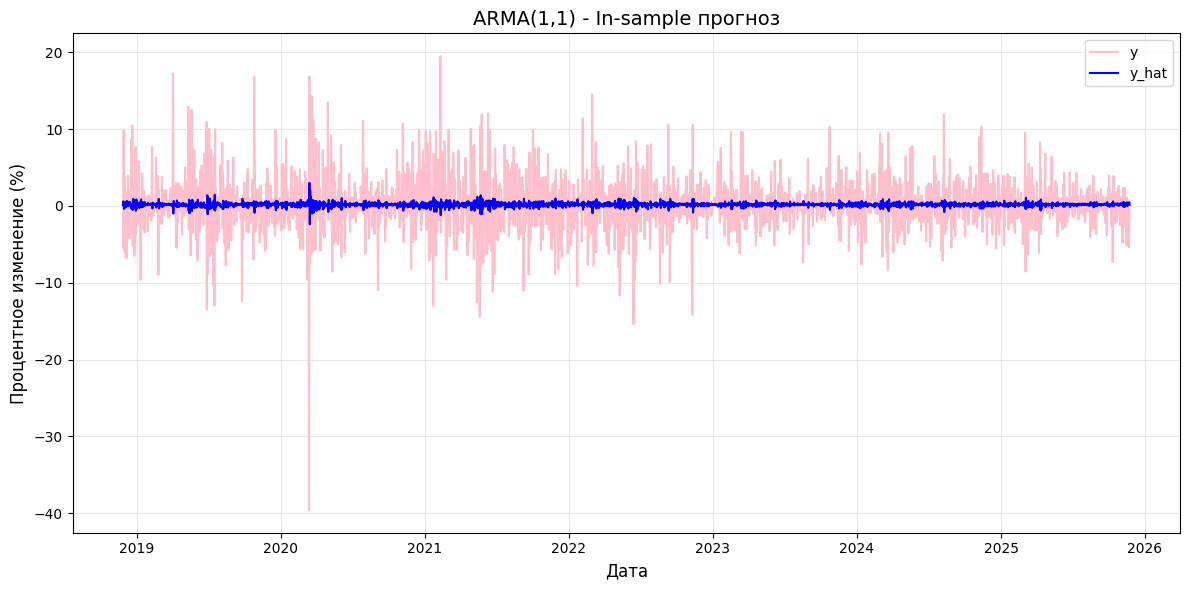

In [258]:
forecast = model.predict()
plt.figure(figsize=(12, 6))
plt.plot(df_prs,color='pink')
plt.plot(forecast,color='blue')
plt.legend(['y','y_hat'])
plt.title("ARMA(1,1) - In-sample прогноз",fontsize=14)
plt.xlabel('Дата', fontsize=12)
plt.ylabel('Процентное изменение (%)', fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Как видим из графика in sample прогноз, визуально повторячет поведение изначального временного ряда. Только значительно сильно меньше

#Прогноз ARMA out of sample

In [259]:
train_size = int(len(df_prs) * 0.8)
train, test = df_prs[:train_size], df_prs[train_size:]

model = ARIMA(train, order=(1,0,1))
model = model.fit()

forecast_size = len(test)

y_hat = model.forecast(steps=forecast_size)
y_hat = pd.DataFrame(y_hat)
y_hat['ds'] = test.index
y_hat = y_hat.set_index('ds')

fig = px.line(title="ARMA(1,1) - out of sample прогноз ")
fig.add_scatter(x=train.index, y=train['pct_change'], mode='lines', name='train', line=dict(color='blue'))
fig.add_scatter(x=test.index, y=test['pct_change'], mode='lines', name='test', line=dict(color='green'))
fig.add_scatter(x=y_hat.index, y=y_hat['predicted_mean'], mode='lines', name='forecast', line=dict(color='red'))


fig.update_layout(template='plotly_white', width=1000, height=500)
fig.update_xaxes(title_text="Дата")
fig.update_yaxes(title_text="процентное изменение")
fig.show()



Как видно из графика , модель не смогла уловить динамику поведения ряда. Просто дав околонулевой прогноз. Возможно из за того , что на данный момент рассматривается ряд приведенный к стационарному. Восстановим изначальный ряд и прогноз к нему

In [260]:
y_hat.columns = ['pct_change']
btc_forecasted = pd.concat([train, y_hat])
btc_forecasted.head(-10)

,pct_change
ds,
2018-11-27,-5.442443
2018-11-28,0.383023
2018-11-29,9.820047
2018-11-30,0.840435
2018-12-01,-5.934117
...,...
2025-11-09,0.195776
2025-11-10,0.195776
2025-11-11,0.195776


In [261]:
btc_forecasted['y_restored'] = df['y'].iloc[0]
for i in range(1, len(btc_forecasted)):
    btc_forecasted['y_restored'].iloc[i] = btc_forecasted['y_restored'].iloc[i-1] * (1 + btc_forecasted['pct_change'].iloc[i] / 100)
btc_forecasted.head(-10)


,pct_change,y_restored
ds,,
2018-11-27,-5.442443,4086.400000
2018-11-28,0.383023,4102.051843
2018-11-29,9.820047,4504.875280
2018-11-30,0.840435,4542.735818
2018-12-01,-5.934117,4273.164555
...,...,...
2025-11-09,0.195776,170282.886387
2025-11-10,0.195776,170616.258856
2025-11-11,0.195776,170950.283988


In [262]:
fig = px.line(title="ARMA(1,1) - out of-sample прогноз")
fig.add_scatter(x=df.index[:train_size], y=df['y'][:train_size], mode='lines', name='y(train)', line=dict(color='blue'))
fig.add_scatter(x=df.index[train_size:], y=df['y'][train_size:], mode='lines', name='y(test)', line=dict(color='green'))
fig.add_scatter(x=btc_forecasted.index[train_size:], y=btc_forecasted['y_restored'][train_size:], mode='lines', name='y_predict', line=dict(color='red'))



fig.update_layout(template='plotly_white', width=1000, height=500)
fig.update_xaxes(title_text="Дата")
fig.update_yaxes(title_text="цена")
fig.show()

arma_metric = metrics(df['y'][train_size:],btc_forecasted['y_restored'][train_size-1:])
arma_metric


RMSE: 27005.80
MAPE: 22.34%


(27005.8, 22.34)

Как видим из восстановленного графика, можель ARMA(1,1) смогла уловить общий тренд в начале, но во второй половине тестового периода резковато уходит вверх, тогда как сам ряд испытывает падение, то есть видно сильное расхождение в поведении ряда и предсказания. Метрики качества так же показывают наша модель ошибаентся на 22.34 %. И среднеквадратичная ошибка  27005 достаточно большое, что так же говорит нам о значительном расхождении между прогнозом и реальными данными


# Прогноз in sample ARIMA

Подберем наилучшую модель ARIMA для  in-sample прогноза, с помощью auto - ARIMA. Так как наш ряд нестационарный , для модели ARIMA не нужно приводить к стационарности, так как у нее есть втроенное дифференцирование(интегрирование)

In [263]:
model = auto_arima(df['y'], stepwise=True, trace=True)

print(model.summary())

Performing stepwise search to minimize aic
 ARIMA(2,1,2)(0,0,0)[0] intercept   : AIC=44137.750, Time=4.56 sec
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=44136.551, Time=0.09 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=44134.049, Time=0.11 sec
 ARIMA(0,1,1)(0,0,0)[0] intercept   : AIC=44134.067, Time=0.20 sec
 ARIMA(0,1,0)(0,0,0)[0]             : AIC=44135.912, Time=0.05 sec
 ARIMA(2,1,0)(0,0,0)[0] intercept   : AIC=44136.049, Time=0.27 sec
 ARIMA(1,1,1)(0,0,0)[0] intercept   : AIC=44136.051, Time=0.25 sec
 ARIMA(2,1,1)(0,0,0)[0] intercept   : AIC=44138.051, Time=0.41 sec
 ARIMA(1,1,0)(0,0,0)[0]             : AIC=44133.533, Time=0.09 sec
 ARIMA(2,1,0)(0,0,0)[0]             : AIC=44135.532, Time=0.14 sec
 ARIMA(1,1,1)(0,0,0)[0]             : AIC=44135.534, Time=0.12 sec
 ARIMA(0,1,1)(0,0,0)[0]             : AIC=44133.553, Time=0.12 sec
 ARIMA(2,1,1)(0,0,0)[0]             : AIC=44137.533, Time=0.23 sec

Best model:  ARIMA(1,1,0)(0,0,0)[0]          
Total fit time: 6.664 seconds
         

как видим из результата, наилучшие параметры для in sample прогноза ARIMA это (1,1,0). Причем все коэффициенты статистически значимы

In [264]:
model = ARIMA(df['y'], order=(1,1,0))
model = model.fit()
forecast = model.predict()


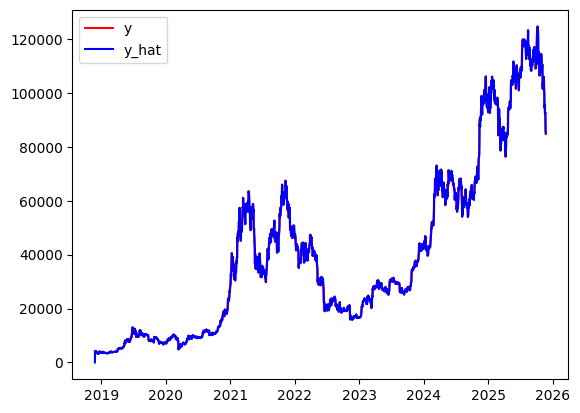

In [265]:
plt.plot(df['y'],color='red')
plt.plot(forecast,color='blue')
plt.legend(['y','y_hat'])
plt.show()

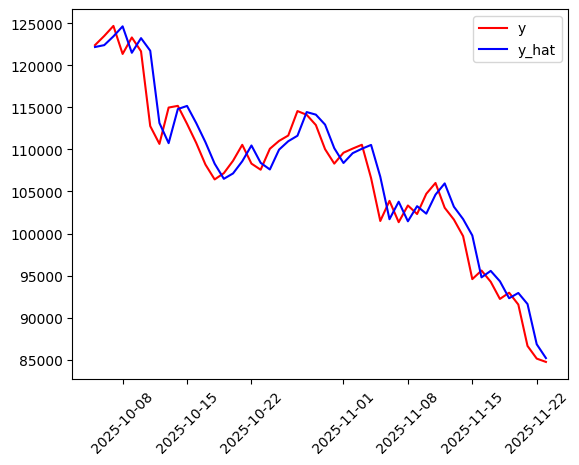

In [266]:
plt.plot(df['y'][-50:],color='red')
plt.plot(forecast[-50:],color='blue')
plt.legend(['y','y_hat'])
plt.xticks(rotation=45)
plt.show()

Как видим из in-sample прогноза, модель показывает очень высокую точность, а значит изначальные параметры (1,1,0) были правильно подобраны , и наша модель хорошо описывает поведение изначального ряда. А значит можно переходить к out of sample прогнозу


# Прогноз ARIMA out-of-sample

Подберем наилучшую модель ARIMA для out of sample прогноза, с помощью auto - ARIMA.

In [267]:
train_size = int(len(df['y']) * 0.9)
train, test = df['y'][:train_size], df['y'][train_size:]
model = auto_arima(train, stepwise=True, trace=True)

print(model.summary())

Performing stepwise search to minimize aic
 ARIMA(2,1,2)(0,0,0)[0] intercept   : AIC=39366.592, Time=2.08 sec
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=39371.315, Time=0.10 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=39367.688, Time=0.10 sec
 ARIMA(0,1,1)(0,0,0)[0] intercept   : AIC=39367.732, Time=0.23 sec
 ARIMA(0,1,0)(0,0,0)[0]             : AIC=39370.993, Time=0.05 sec
 ARIMA(1,1,2)(0,0,0)[0] intercept   : AIC=39371.672, Time=1.08 sec
 ARIMA(2,1,1)(0,0,0)[0] intercept   : AIC=39371.684, Time=0.42 sec
 ARIMA(3,1,2)(0,0,0)[0] intercept   : AIC=inf, Time=4.90 sec
 ARIMA(2,1,3)(0,0,0)[0] intercept   : AIC=39371.819, Time=3.33 sec
 ARIMA(1,1,1)(0,0,0)[0] intercept   : AIC=39369.689, Time=0.23 sec
 ARIMA(1,1,3)(0,0,0)[0] intercept   : AIC=39373.204, Time=1.25 sec
 ARIMA(3,1,1)(0,0,0)[0] intercept   : AIC=39373.328, Time=1.01 sec
 ARIMA(3,1,3)(0,0,0)[0] intercept   : AIC=39369.249, Time=4.52 sec
 ARIMA(2,1,2)(0,0,0)[0]             : AIC=39366.747, Time=1.52 sec

Best model:  ARIMA(2,1,2

Как видим из результата, наилучшие параметры для out of sample прогноза ARIMA это (2,1,2). Причем все коэффициенты статистически значимы

In [268]:
forecast_auto_arima = model.predict(n_periods=len(test))
forecast_auto_arima = pd.DataFrame(forecast_auto_arima)
forecast_auto_arima['ds'] = test.index
forecast_auto_arima.set_index('ds', inplace=True)
forecast_auto_arima.columns = ['y_hat']

forecast_auto_arima

,y_hat
ds,
2025-03-13,82533.247179
2025-03-14,82189.061691
2025-03-15,82299.724227
2025-03-16,82716.764393
2025-03-17,82988.960580
...,...
2025-11-19,90768.257392
2025-11-20,90801.062279
2025-11-21,90833.867168


In [269]:
fig = px.line(title="Цена Биткоина модель ARIMA(2,1,2) out of sample прогноз")
fig.add_scatter(x=train.index, y=train, mode='lines', name='train', line=dict(color='blue'))
fig.add_scatter(x=test.index, y=test, mode='lines', name='test', line=dict(color='green'))
fig.add_scatter(x=forecast_auto_arima.index, y=forecast_auto_arima['y_hat'], mode='lines', name='forecast', line=dict(color='red'))


fig.update_layout(template='plotly_white', width=800, height=500)
fig.update_xaxes(title_text="Дата")
fig.update_yaxes(title_text="цена")
fig.show()

arima_metric_out = metrics(test,forecast_auto_arima['y_hat'])
arima_metric_out

RMSE: 21177.83
MAPE: 16.90%


(21177.83, 16.9)

Модель ARIMA(2,1,2) показала низкую эффективность в прогнозировании  на тестовой выборке. То есть модель не способна уловить резкие всплески.Она уловила лишь начальный тренд, и то прогноз  представляет собой очень гладкую, почти линейную траекторию, которая не смогла уловить ни резкий рост, ни последующее резкое падение, наблюдавшиеся в фактических данных. Несмотря на то что модель ARIMA, показала отличное поведениена in sample, она оказалась не очень хороша для краткосрочного прогнозирования цены Биткоина в периоды высокой волатильности, так как ее прогнозы слишком сглажены и не учитывают внезапные рыночные события. Метрики качества так же показывают наша модель ошибаентся на 16.9 %. И среднеквадратичная ошибка  21177 достаточно большое, что так же говорит нам о значительном расхождении между прогнозом и реальными данными. Но данная модель показывает уже лучше результат, нежели ARMA(1,1). Средняя абсолютная процентная ошибка уменьшилась на 5.5%

# ARIMAX модель dummy регрессор

Подберем dummy регрессор. Период праздников и выходных в США. Несмотря на то, что рынок криптовалют работает круглосуточно, в периоды празников или выходных может наблюдаться изменение в ликвидности, объёмах торгов и даже общей динамике цен на биткоин, поскольку снижается участие крупных игроков.

In [270]:
df = pd.read_csv('btc_usdt_7years_okx.csv')
df['datetime'] = pd.to_datetime(df['datetime'])
df.rename(columns={'datetime':'ds', 'open':'y'}, inplace=True)
df['y'] = df['y'].astype(float)
df = df[['ds', 'y']].sort_values(by='ds').set_index('ds')
regressors = pd.DataFrame(index=df.index)

regressors['is_weekend'] = (df.index.dayofweek >= 5).astype(int)

holiday_dates = [
    '2018-01-01', '2018-01-15', '2018-02-19', '2018-05-28', '2018-07-04', '2018-09-03', '2018-11-22', '2018-12-25',

    '2019-01-01', '2019-01-21', '2019-02-18', '2019-05-27', '2019-07-04', '2019-09-02', '2019-11-28', '2019-12-25',

    '2020-01-01', '2020-01-20', '2020-02-17', '2020-05-25', '2020-07-04', '2020-09-07', '2020-11-26', '2020-12-25',

    '2021-01-01', '2021-01-18', '2021-02-15', '2021-05-31', '2021-07-04', '2021-09-06', '2021-11-25', '2021-12-25',

    '2022-01-01', '2022-01-17', '2022-02-21', '2022-05-30', '2022-07-04', '2022-09-05', '2022-11-24', '2022-12-25',

    '2023-01-01', '2023-01-16', '2023-02-20', '2023-05-29', '2023-07-04', '2023-09-04', '2023-11-23', '2023-12-25',

    '2024-01-01', '2024-01-15', '2024-02-19', '2024-05-27', '2024-07-04', '2024-09-02', '2024-11-28', '2024-12-25',

    '2025-01-01', '2025-01-20', '2025-02-17', '2025-05-26', '2025-07-04', '2025-09-01', '2025-11-27', '2025-12-25'
]

regressors['is_holiday'] = df.index.isin(pd.to_datetime(holiday_dates)).astype(int)

train_size = int(len(df) * 0.9)
train, test = df['y'][:train_size], df['y'][train_size:]
regressors_train = regressors[:train_size]
regressors_test = regressors[train_size:]


model_with_reg = auto_arima(train, X=regressors_train[['is_weekend', 'is_holiday']], stepwise=True, trace=True)

forecast_with_reg = model_with_reg.predict(n_periods=len(test), X=regressors_test[[ 'is_weekend', 'is_holiday']])
forecast_with_reg_df = pd.DataFrame(forecast_with_reg ,index=test.index, columns=['y_hat'])


fig = px.line(title="Прогноз out of sample ARIMA модели с dummy регрессором")
fig.add_scatter(x=train.index, y=train, mode='lines', name='Train', line=dict(color='blue'))
fig.add_scatter(x=test.index, y=test, mode='lines', name='Test', line=dict(color='green'))
fig.add_scatter(x=forecast_with_reg_df.index, y=forecast_with_reg_df['y_hat'], mode='lines',name='Предсказание с dummy регрессором', line=dict(color='orange'))

fig.update_layout(template='plotly_white', width=800, height=500)
fig.update_xaxes(title_text="Дата")
fig.update_yaxes(title_text="Цена")
fig.show()

arimax_metric_out_dummy = metrics(test,forecast_with_reg_df['y_hat'])
arimax_metric_out_dummy

Performing stepwise search to minimize aic
 ARIMA(2,1,2)(0,0,0)[0] intercept   : AIC=39370.294, Time=4.74 sec
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=39374.982, Time=0.14 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=39371.449, Time=0.20 sec
 ARIMA(0,1,1)(0,0,0)[0] intercept   : AIC=39371.487, Time=0.30 sec
 ARIMA(0,1,0)(0,0,0)[0]             : AIC=39374.791, Time=0.75 sec
 ARIMA(1,1,2)(0,0,0)[0] intercept   : AIC=39375.440, Time=1.38 sec
 ARIMA(2,1,1)(0,0,0)[0] intercept   : AIC=39375.448, Time=0.69 sec
 ARIMA(3,1,2)(0,0,0)[0] intercept   : AIC=39371.427, Time=4.61 sec
 ARIMA(2,1,3)(0,0,0)[0] intercept   : AIC=39375.644, Time=4.94 sec
 ARIMA(1,1,1)(0,0,0)[0] intercept   : AIC=39373.451, Time=0.35 sec
 ARIMA(1,1,3)(0,0,0)[0] intercept   : AIC=39376.957, Time=1.57 sec
 ARIMA(3,1,1)(0,0,0)[0] intercept   : AIC=39377.084, Time=1.54 sec
 ARIMA(3,1,3)(0,0,0)[0] intercept   : AIC=39373.031, Time=7.22 sec
 ARIMA(2,1,2)(0,0,0)[0]             : AIC=39370.339, Time=2.99 sec

Best model:  ARIMA

RMSE: 21168.42
MAPE: 16.89%


(21168.42, 16.89)

ARIMAX с dummy‑регрессором(периоды праздников и выходных), практически не изменила качество: метрики, которые были RMSE: 21177.83
MAPE: 16.90% , стали RMSE: 21168.42
MAPE: 16.89%, то есть улучшение минимальное и прогноз ведёт себя так же, как в out‑of‑sample — резких улучшений или захвата дополнительных пиков/падений не произошло.Единсвенный момент, если посмотреть на самое начало в тестовом ряду прогноз постарался уловить поведение ряда, но буквально на месяц, далее прогноз ведет себя как гладкая прямая .Это говорит о том, что подобранный dummy регрессор даёт мало дополнительной информации для модели.

# Прогноз in sample ARIMAX с непрерывным регрессором 1

Возьмем непрерывный регрессор, стоимость акций NVIDIA. Так как Bitcoin и другие криптовалюты активно добывают с помощью мощных видеокарт,один из производителей которых NVIDIA

In [271]:
nvda_from_file = pd.read_csv('nvidia_open_price_clean.csv', index_col=0, parse_dates=True)
nvda_from_file.columns = ['nvidia_price']

nvda_aligned = nvda_from_file.reindex(df.index)
nvda_regressor = pd.DataFrame({'nvidia_price': nvda_aligned['nvidia_price']})

train_reg = nvda_regressor.fillna(method='ffill').fillna(method='bfill')


model_nvda = auto_arima(df['y'], X=train_reg, stepwise=True, trace=False, suppress_warnings=True )

forecast_nvda = model_nvda.predict_in_sample(X=train_reg)
forecast_nvda = np.asarray(forecast_nvda)

index_full = df.index

forecast_nvda_df = pd.DataFrame(forecast_nvda.reshape(-1, 1), index=index_full, columns=['y_hat'])


fig = px.line(title="Bitcoin In-Sample прогноз модель ARIMAX с регрессором акции NVIDIA")
fig.add_scatter(x=df.index, y=df['y'], mode='lines', name='Цена на Bitcoin', line=dict(color='blue'))
fig.add_scatter(x=forecast_nvda_df.index, y=forecast_nvda_df['y_hat'], mode='lines',
                name='с регрессором NVIDIA', line=dict(color='orange'))

fig.update_layout(template='plotly_white', width=1000, height=800)
fig.update_xaxes(title_text="Дата")
fig.update_yaxes(title_text="Цена")
fig.show()




Как видим из in-sample прогноза, модель показывает очень высокую точность, а значит изначальные параметры (2,1,2) были правильно подобраны , и наша модель хорошо описывает поведение изначального ряда. А значит можно переходить к out of sample прогнозу

# Прогноз out of sample ARIMAX с непрерывным регрессором 1

In [272]:
nvda_from_file = pd.read_csv('nvidia_open_price_clean.csv', index_col=0, parse_dates=True)
nvda_from_file.columns = ['nvidia_price']

nvda_aligned = nvda_from_file.reindex(df.index, method='ffill')
nvda_regressor = pd.DataFrame({'nvidia_price': nvda_aligned['nvidia_price']})

train_size = int(len(df) * 0.8)
train = df['y'][:train_size]
test = df['y'][train_size:]
train_reg = nvda_regressor[:train_size]
test_reg = nvda_regressor[train_size:]
forecast_size = len(test)


model_nvda = auto_arima(train, X=train_reg[['nvidia_price']], stepwise=True, trace=True)

forecast_nvda = model_nvda.predict(n_periods=forecast_size, X=test_reg[['nvidia_price']])
forecast_nvda_df = pd.DataFrame(forecast_nvda, index=test.index, columns=['y_hat'])

fig = px.line(title="Стоимость Bitcoin out of sample прогноз ARIMAX с непрерывным регрессором -акции NVIDIA")
fig.add_scatter(x=train.index, y=train, mode='lines', name='Train', line=dict(color='blue'))
fig.add_scatter(x=test.index, y=test, mode='lines', name='Test', line=dict(color='green'))

fig.add_scatter(x=forecast_nvda_df.index, y=forecast_nvda_df['y_hat'], mode='lines',
                name='С регрессором NVIDIA', line=dict(color='orange'))

fig.update_layout(template='plotly_white', width=1000, height=800)
fig.update_xaxes(title_text="Дата")
fig.update_yaxes(title_text="Цена")
fig.show()


fig = go.Figure()

fig.add_trace(go.Scatter(
    x=df.index,
    y=df['y'],
    mode='lines',
    name='Цена Биткойна',
    line=dict(color='orange'),
    yaxis='y1'
))

fig.add_trace(go.Scatter(
    x=nvda_from_file.index,
    y=nvda_from_file['nvidia_price'],
    mode='lines',
    name='Цена NVIDIA ',
    line=dict(color='green'),
    yaxis='y2'
))

fig.update_layout(
    title="Цены Биткоина и NVIDIA",
    template='plotly_white',
    width=1000,
    height=500,
    yaxis=dict(
        title='Цена Биткойна (USDT)',
        titlefont=dict(color='orange'),
        tickfont=dict(color='orange')
    ),
    yaxis2=dict(
        title='Цена NVIDIA (USDT)',
        titlefont=dict(color='green'),
        tickfont=dict(color='green'),
        overlaying='y',
        side='right'
    ),
    xaxis=dict(title='Date')
)

fig.show()
arimax_metric_out_1 = metrics(test,forecast_nvda_df['y_hat'])
arimax_metric_out_1

Performing stepwise search to minimize aic
 ARIMA(2,1,2)(0,0,0)[0] intercept   : AIC=34433.948, Time=1.58 sec
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=34443.463, Time=0.09 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=34435.516, Time=0.11 sec
 ARIMA(0,1,1)(0,0,0)[0] intercept   : AIC=34435.819, Time=0.24 sec
 ARIMA(0,1,0)(0,0,0)[0]             : AIC=34442.111, Time=0.53 sec
 ARIMA(1,1,2)(0,0,0)[0] intercept   : AIC=34437.640, Time=1.06 sec
 ARIMA(2,1,1)(0,0,0)[0] intercept   : AIC=34438.386, Time=1.44 sec
 ARIMA(3,1,2)(0,0,0)[0] intercept   : AIC=34434.018, Time=4.38 sec
 ARIMA(2,1,3)(0,0,0)[0] intercept   : AIC=34434.177, Time=3.85 sec
 ARIMA(1,1,1)(0,0,0)[0] intercept   : AIC=34437.391, Time=0.29 sec
 ARIMA(1,1,3)(0,0,0)[0] intercept   : AIC=34437.631, Time=1.30 sec
 ARIMA(3,1,1)(0,0,0)[0] intercept   : AIC=34438.243, Time=1.32 sec
 ARIMA(3,1,3)(0,0,0)[0] intercept   : AIC=34437.685, Time=2.87 sec
 ARIMA(2,1,2)(0,0,0)[0]             : AIC=34432.397, Time=2.28 sec
 ARIMA(1,1,2)(0,0,0

RMSE: 33385.47
MAPE: 28.46%


(33385.47, 28.46)

Как видно из общего графика, цены Биткоина и NVIDIA достаточно хорошо коррелируют с 2023 года; до этого NVIDIA была относительно стационарна по сравнению с резкими скачками Биткоина, при этом уровень цены Биткоина существенно выше уровня NVIDIA. В out of sample прогнозе кривая в целом повторяет поведение тестовой выборки, но с заметно меньшей дисперсией — то есть прогноз слишком сглажен и не отражает всех колебаний. Метрики качества  остаются неудовлетворительными: MAPE равен 28.46%, что указывает на высокую относительную ошибку, и среднеквадратичная ошибка высокая 33 385.Обе метрики показывают качесво хуже чем модель ARIMA(2,1,2)  Следовательно, несмотря на наблюдаемую долгосрочную связь, ARIMAX не сумел эффективно использовать влияние акций NVIDIA для повышения краткосрочной точности прогноза.

# Прогноз in sample ARIMAX с непрерывным регрессором 2

Возьмем второй непрерывный регрессор, стоимость Ethereum

In [273]:
eth_from_file = pd.read_csv('ethereum_open_price_clean.csv', index_col=0, parse_dates=True)
eth_from_file.columns = ['eth_price']


eth_aligned = eth_from_file.reindex(df.index)
eth_aligned['eth_price'] = eth_aligned['eth_price'].fillna(method='ffill').fillna(method='bfill')

eth_regressor = pd.DataFrame({'eth_price': eth_aligned['eth_price']})

train_reg_eth = eth_regressor.fillna(method='ffill').fillna(method='bfill')

model_eth = auto_arima(df['y'], X=train_reg_eth, stepwise=True, trace=False, suppress_warnings=True )

forecast_eth = model_eth.predict_in_sample(X=train_reg_eth)
forecast_eth = np.asarray(forecast_eth)
index_full = df.index


forecast_eth_df = pd.DataFrame(forecast_eth.reshape(-1, 1),index=index_full, columns=['y_hat'])

fig = px.line(title="Bitcoin In-Sample прогноз ARIMAX с регрессором Ethereum ")

fig.add_scatter(x=df.index, y=df['y'], mode='lines', name='Цена Bitcoin', line=dict(color='blue'))

fig.add_scatter(x=forecast_eth_df.index, y=forecast_eth_df['y_hat'], mode='lines',
                name='прогноз с Ethereum', line=dict(color='green'))
fig.update_layout(template='plotly_white', width=1000, height=800)
fig.update_xaxes(title_text="Дата")
fig.update_yaxes(title_text="Цена")
fig.show()

Как видим из in-sample прогноза, модель показывает очень высокую точность, а значит изначальные параметры (2,1,2) были правильно подобраны , и наша модель хорошо описывает поведение изначального ряда. А значит можно переходить к out of sample прогнозу

# Прогноз out of sample ARIMAX с непрерывным регрессором 2

In [274]:
eth_from_file = pd.read_csv('ethereum_open_price_clean.csv', index_col=0, parse_dates=True)
eth_from_file.columns = ['eth_price']

eth_aligned = eth_from_file.reindex(df.index)
eth_aligned['eth_price'] = eth_aligned['eth_price'].fillna(method='ffill').fillna(method='bfill')

eth_regressor = pd.DataFrame({'eth_price': eth_aligned['eth_price']})

train_size = int(len(df) * 0.9)
train = df['y'][:train_size]
test = df['y'][train_size:]
train_reg = eth_regressor[:train_size]
test_reg = eth_regressor[train_size:]
forecast_size = len(test)


model_eth = auto_arima(train, X=train_reg[['eth_price']], stepwise=True,  seasonal=False, trace=True, suppress_warnings=True)

forecast_eth = model_eth.predict(n_periods=forecast_size,
                               X=test_reg[['eth_price']])
forecast_eth_df = pd.DataFrame(forecast_eth, index=test.index, columns=['y_hat'])

fig = px.line(title="Цена Bitcoin out of sample прогноз ARIMAX c регрессором Ethereum ")
fig.add_scatter(x=df.index, y=df['y'], mode='lines', name='Цена на Bitcoin', line=dict(color='blue'))
fig.add_scatter(x=forecast_eth_df.index, y=forecast_eth_df['y_hat'], mode='lines',
                name='С регрессором Ethereum', line=dict(color='purple'))

fig.update_layout(template='plotly_white', width=1000, height=800)
fig.update_xaxes(title_text="Дата")
fig.update_yaxes(title_text="Цена")
fig.show()


fig = go.Figure()

fig.add_trace(go.Scatter(
    x=df.index,
    y=df['y'],
    mode='lines',
    name='Цена Биткойна',
    line=dict(color='orange'),
    yaxis='y1'
))

fig.add_trace(go.Scatter(
    x=eth_from_file.index,
    y=eth_from_file['eth_price'],
    mode='lines',
    name='Цена  Ethereum ',
    line=dict(color='green'),
    yaxis='y2'
))

fig.update_layout(
    title="Цены Биткоина и Ethereum",
    template='plotly_white',
    width=1000,
    height=500,
    yaxis=dict(
        title='Цена Биткойна (USDT)',
        titlefont=dict(color='orange'),
        tickfont=dict(color='orange')
    ),
    yaxis2=dict(
        title='Цена  Ethereum (USDT)',
        titlefont=dict(color='green'),
        tickfont=dict(color='green'),
        overlaying='y',
        side='right'
    ),
    xaxis=dict(title='Date')
)

fig.show()

arimax_metric_out_2 = metrics(test,forecast_eth_df['y_hat'])
arimax_metric_out_2

Performing stepwise search to minimize aic
 ARIMA(2,1,2)(0,0,0)[0] intercept   : AIC=37331.961, Time=1.72 sec
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=37328.712, Time=0.22 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=37330.700, Time=0.21 sec
 ARIMA(0,1,1)(0,0,0)[0] intercept   : AIC=37330.703, Time=0.59 sec
 ARIMA(0,1,0)(0,0,0)[0]             : AIC=37328.968, Time=0.79 sec
 ARIMA(1,1,1)(0,0,0)[0] intercept   : AIC=37332.702, Time=0.64 sec

Best model:  ARIMA(0,1,0)(0,0,0)[0] intercept
Total fit time: 4.192 seconds


RMSE: 9393.42
MAPE: 7.00%


(9393.42, 7.0)


Как видно из общего графика, цены Биткоина и Ethereum достаточно хорошо коррелируют с 2019 года. Визуально в out of sample прогнозе кривая в целом близко повторяет поведение тестовой выборки, сохраняя динамику и волатильность на уровне реального ряда. По метрикам качества, можно сделать однозначно положительный вывод: включение Ethereum в качестве непрерывного регрессора заметно улучшило качество прогноза по сравнению с предыдущими моделями — абсолютные ошибки существенно уменьшились процент ошибки снизился 7%, что на 10 процентов меньше по сравнению с другими моделями, а так же среднеквадратичная ошибка уменьшилась в 3 раза.

In [275]:
print(f"ARMA: RMSE={arma_metric[0]}, MAPE={arma_metric[1]}%")
print(f"ARIMA: RMSE={arima_metric_out[0]}, MAPE={arima_metric_out[1]}%")
print(f"ARIMAX dummy: RMSE={arimax_metric_out_dummy[0]}, MAPE={arimax_metric_out_dummy[1]}%")
print(f"ARIMAX 1: RMSE={arimax_metric_out_1[0]}, MAPE={arimax_metric_out_1[1]}%")
print(f"ARIMAX 2: RMSE={arimax_metric_out_2[0]}, MAPE={arimax_metric_out_2[1]}%")

ARMA: RMSE=27005.8, MAPE=22.34%
ARIMA: RMSE=21177.83, MAPE=16.9%
ARIMAX dummy: RMSE=21168.42, MAPE=16.89%
ARIMAX 1: RMSE=33385.47, MAPE=28.46%
ARIMAX 2: RMSE=9393.42, MAPE=7.0%


Итоговая модель — ARIMAX с непрерывным регрессором Ethereum , обученная на исторических ценах Биткоина с добавлением в качестве внешнего объясняющего признака  цены Ethereum. По итогам валидации out of sample модель показала RMSE 9393.42 и MAPE = 7.0%, что является заметным улучшением по сравнению с предыдущими попытками без  регрессора и с регрессором, но менее подходящим. Визуальный анализ прогноза показывает, что модель с Ethereum лучше повторяет динамику тестовой выборки, сохраняет амплитуду и локальные колебания цены Биткоина ближе к реальным значениям и при этом не слишком сглаживает ряд, как это делали более простые ARIMA или ARIMAX с dummy регрессором.

Причины, по которым выбранная ARIMAX с регрессором Ethereum показала лучшие результаты в данном временном ряду, следующие. Во‑первых, после 2023 года наблюдается устойчивая корреляция между Bitcoin и Ethereum: оба актива реагируют на общие макро‑и криптофакторы (ликвидность, настроения рынка, регуляторные новости, технологические события), поэтому информация из цен Ethereum помогает объяснять часть вариативности Bitcoin, которую чистая ARIMA не улавливала. Во‑вторых, непрерывный регрессор (а не бинарные dummy) предоставляет модели количественную входную переменную, способную захватывать пропорциональные изменения и временные сдвиги корреляции, что снижает остаточную дисперсию и улучшает предсказуемость. В‑третьих, выбранная структура AR(1) с интегрированием d=1 позволяет модели учитывать короткую автокорреляцию и тренд, а внешний регрессор компенсирует недостающие внешние шоки, тем самым улучшая краткосрочную точность.

Второй датасет стоимость акций Xiaomi

In [49]:
df_mi = pd.read_csv('xiaomi_6years.csv')
df_mi

,Price,Close,High,Low,Open,Volume
0,Ticker,1810.HK,1810.HK,1810.HK,1810.HK,1810.HK
1,Date,NaN,NaN,NaN,NaN,NaN
2,2019-12-02,8.930000305175781,9.020000457763672,8.829999923706055,8.970000267028809,107412610
3,2019-12-03,9.010000228881836,9.050000190734863,8.800000190734863,8.930000305175781,147325642
4,2019-12-04,9.0,9.15999984741211,8.920000076293945,8.9399995803833,134747942
...,...,...,...,...,...,...
1473,2025-11-25,40.34000015258789,41.099998474121094,39.58000183105469,39.79999923706055,317034207
1474,2025-11-26,40.099998474121094,41.119998931884766,39.900001525878906,40.58000183105469,200500143
1475,2025-11-27,41.099998474121094,41.79999923706055,40.220001220703125,40.2400016784668,209296970
1476,2025-11-28,41.02000045776367,41.20000076293945,40.619998931884766,41.18000030517578,85614446


In [50]:
df_mi = df_mi.iloc[2:].reset_index(drop=True)
df_mi

,Price,Close,High,Low,Open,Volume
0,2019-12-02,8.930000305175781,9.020000457763672,8.829999923706055,8.970000267028809,107412610
1,2019-12-03,9.010000228881836,9.050000190734863,8.800000190734863,8.930000305175781,147325642
2,2019-12-04,9.0,9.15999984741211,8.920000076293945,8.9399995803833,134747942
3,2019-12-05,9.069999694824219,9.100000381469727,8.960000038146973,9.100000381469727,100317107
4,2019-12-06,9.34000015258789,9.350000381469727,9.039999961853027,9.069999694824219,227486578
...,...,...,...,...,...,...
1471,2025-11-25,40.34000015258789,41.099998474121094,39.58000183105469,39.79999923706055,317034207
1472,2025-11-26,40.099998474121094,41.119998931884766,39.900001525878906,40.58000183105469,200500143
1473,2025-11-27,41.099998474121094,41.79999923706055,40.220001220703125,40.2400016784668,209296970
1474,2025-11-28,41.02000045776367,41.20000076293945,40.619998931884766,41.18000030517578,85614446


In [51]:
df_mi.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1476 entries, 0 to 1475
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   Price   1476 non-null   object
 1   Close   1476 non-null   object
 2   High    1476 non-null   object
 3   Low     1476 non-null   object
 4   Open    1476 non-null   object
 5   Volume  1476 non-null   object
dtypes: object(6)
memory usage: 69.3+ KB


In [52]:

df_mi["Open"] = df_mi["Open"].astype(float)


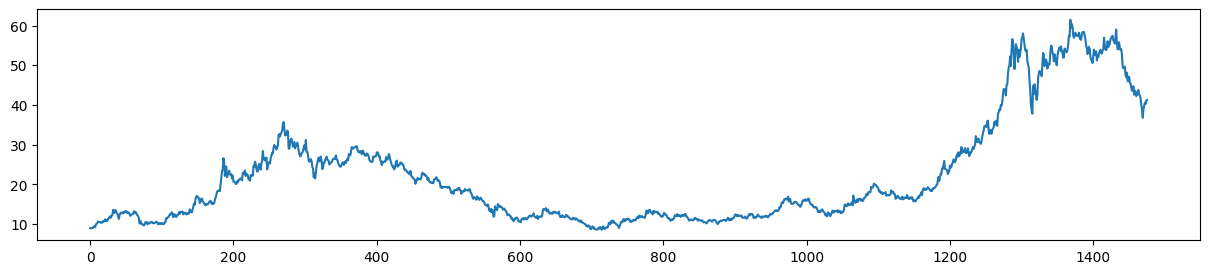

In [53]:
df_mi["Open"].plot(figsize=(15, 3))
plt.show()

In [54]:
df_mi['datetime'] = pd.to_datetime(df_mi['Price'])
df_mi

,Price,Close,High,Low,Open,Volume,datetime
0,2019-12-02,8.930000305175781,9.020000457763672,8.829999923706055,8.970000,107412610,2019-12-02
1,2019-12-03,9.010000228881836,9.050000190734863,8.800000190734863,8.930000,147325642,2019-12-03
2,2019-12-04,9.0,9.15999984741211,8.920000076293945,8.940000,134747942,2019-12-04
3,2019-12-05,9.069999694824219,9.100000381469727,8.960000038146973,9.100000,100317107,2019-12-05
4,2019-12-06,9.34000015258789,9.350000381469727,9.039999961853027,9.070000,227486578,2019-12-06
...,...,...,...,...,...,...,...
1471,2025-11-25,40.34000015258789,41.099998474121094,39.58000183105469,39.799999,317034207,2025-11-25
1472,2025-11-26,40.099998474121094,41.119998931884766,39.900001525878906,40.580002,200500143,2025-11-26
1473,2025-11-27,41.099998474121094,41.79999923706055,40.220001220703125,40.240002,209296970,2025-11-27
1474,2025-11-28,41.02000045776367,41.20000076293945,40.619998931884766,41.180000,85614446,2025-11-28


In [55]:
df_mi.rename(columns={'datetime':'ds', 'Open':'y'}, inplace=True)
df_mi['y'] = df_mi['y'].astype(float)
df_mi = df_mi[['ds', 'y']].sort_values(by='ds').set_index('ds')

df_mi

,y
ds,
2019-12-02,8.970000
2019-12-03,8.930000
2019-12-04,8.940000
2019-12-05,9.100000
2019-12-06,9.070000
...,...
2025-11-25,39.799999
2025-11-26,40.580002
2025-11-27,40.240002


In [56]:
df_mi.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1476 entries, 2019-12-02 to 2025-12-01
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   y       1476 non-null   float64
dtypes: float64(1)
memory usage: 23.1 KB


In [57]:
adf_test(df_mi['y'])


Results of Dickey-Fuller Test:
Test Statistic                   -0.963890
p-value                           0.766206
# Lags Used                       7.000000
Number of Observations Used    1468.000000
Critical Value (1%)              -3.434812
Critical Value (5%)              -2.863511
Critical Value (10%)             -2.567819
dtype: float64


In [58]:
kpss_test(df_mi['y'])

Results of KPSS Test:
Test Statistic            1.94297
p-value                   0.01000
Lags Used                25.00000
Critical Value (10%)      0.34700
Critical Value (5%)       0.46300
Critical Value (2.5%)     0.57400
Critical Value (1%)       0.73900
dtype: float64


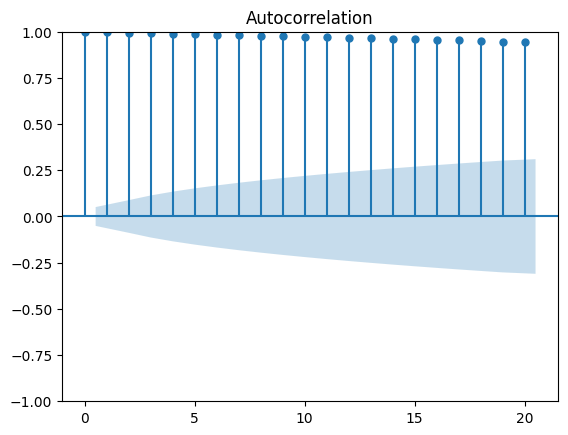

In [59]:
acf_values = acf(df_mi, nlags=20)
plot_acf(np.array(df_mi), lags =20)
plt.show()


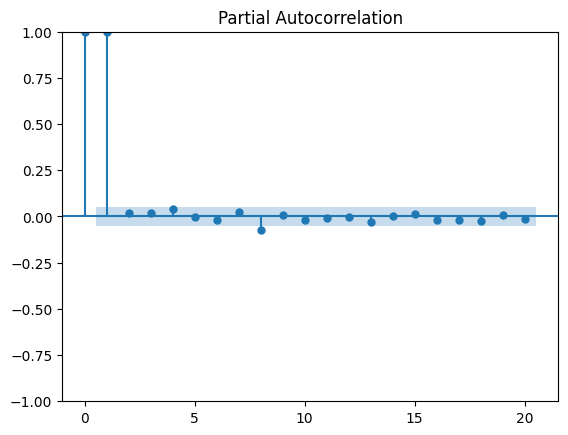

In [60]:
pacf_values = pacf(df_mi, nlags=20)
plot_pacf(np.array(df_mi), lags = 20)
plt.show()

In [61]:
acorr_ljungbox(df_mi, return_df=True)


,lb_stat,lb_pvalue
1,1470.504002,0.0
2,2933.831022,0.0
3,4390.299928,0.0
4,5840.629161,0.0
5,7284.801602,0.0
6,8722.503897,0.0
7,10154.143821,0.0
8,11578.503030,0.0
9,12995.818662,0.0
10,14405.835216,0.0


In [62]:
df_mi['diff'] = df_mi['y'].diff()
df_mi.head()


,y,diff
ds,,
2019-12-02,8.97,NaN
2019-12-03,8.93,-0.040000
2019-12-04,8.94,0.009999
2019-12-05,9.10,0.160001
2019-12-06,9.07,-0.030001


In [63]:
fig = px.line(df_mi, x=df_mi.index, y=df_mi['diff'],
              title="Стоимость акций Xiaomi дифференцированный ряд")

fig.update_layout(template='plotly_white', width=800, height=500)
fig.update_xaxes(title_text="Дата")
fig.update_yaxes(title_text="цена на момент открытия")
fig.show()


In [64]:
adf_test(df_mi['diff'].dropna())

Results of Dickey-Fuller Test:
Test Statistic                -1.322439e+01
p-value                        9.869214e-25
# Lags Used                    6.000000e+00
Number of Observations Used    1.468000e+03
Critical Value (1%)           -3.434812e+00
Critical Value (5%)           -2.863511e+00
Critical Value (10%)          -2.567819e+00
dtype: float64


In [65]:
df_mi['pct_change'] = df_mi['y'].pct_change()*100

fig = px.line(df_mi, x=df_mi.index, y=df_mi['pct_change'],
              title="Стоимость xiaomi ряд, после примененпя процентного прироста")

fig.update_layout(template='plotly_white', width=800, height=500)
fig.update_xaxes(title_text="Дата")
fig.update_yaxes(title_text="цена на момент открытия")
fig.show()

In [66]:
adf_test(df_mi['pct_change'].dropna())


Results of Dickey-Fuller Test:
Test Statistic                -1.391358e+01
p-value                        5.454436e-26
# Lags Used                    6.000000e+00
Number of Observations Used    1.468000e+03
Critical Value (1%)           -3.434812e+00
Critical Value (5%)           -2.863511e+00
Critical Value (10%)          -2.567819e+00
dtype: float64


In [67]:
df_prs = df_mi[['pct_change']].dropna().copy()
df_prs

,pct_change
ds,
2019-12-03,-0.445930
2019-12-04,0.111974
2019-12-05,1.789718
2019-12-06,-0.329678
2019-12-09,3.528122
...,...
2025-11-25,2.577320
2025-11-26,1.959806
2025-11-27,-0.837851


#Прогноз ARMA in sample

In [68]:
best_params = []
for p in np.arange(0,5): # AR with p up to 5 lag
  for q in np.arange(0,5): # MA with q up to 5 lag
    model = ARIMA(df_prs, order=(p,0,q)).fit()
    best_params.append({'p':p, 'q':q, 'AIC':model.aic, 'BIC':model.bic})

pd.DataFrame(best_params).sort_values(by='AIC').head()

,p,q,AIC,BIC
24,4,4,7580.482067,7633.446200
1,0,1,7580.914986,7596.804225
13,2,3,7581.057017,7618.131910
5,1,0,7581.274067,7597.163307
10,2,0,7582.344154,7603.529807


In [69]:
model = ARIMA(df_prs, order=(4,0,4))
model = model.fit()
print(model.summary())

                               SARIMAX Results                                
Dep. Variable:             pct_change   No. Observations:                 1475
Model:                 ARIMA(4, 0, 4)   Log Likelihood               -3780.241
Date:                Fri, 05 Dec 2025   AIC                           7580.482
Time:                        07:59:17   BIC                           7633.446
Sample:                             0   HQIC                          7600.230
                               - 1475                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.1527      0.080      1.911      0.056      -0.004       0.309
ar.L1         -0.7019      0.216     -3.244      0.001      -1.126      -0.278
ar.L2         -0.2999      0.296     -1.015      0.3

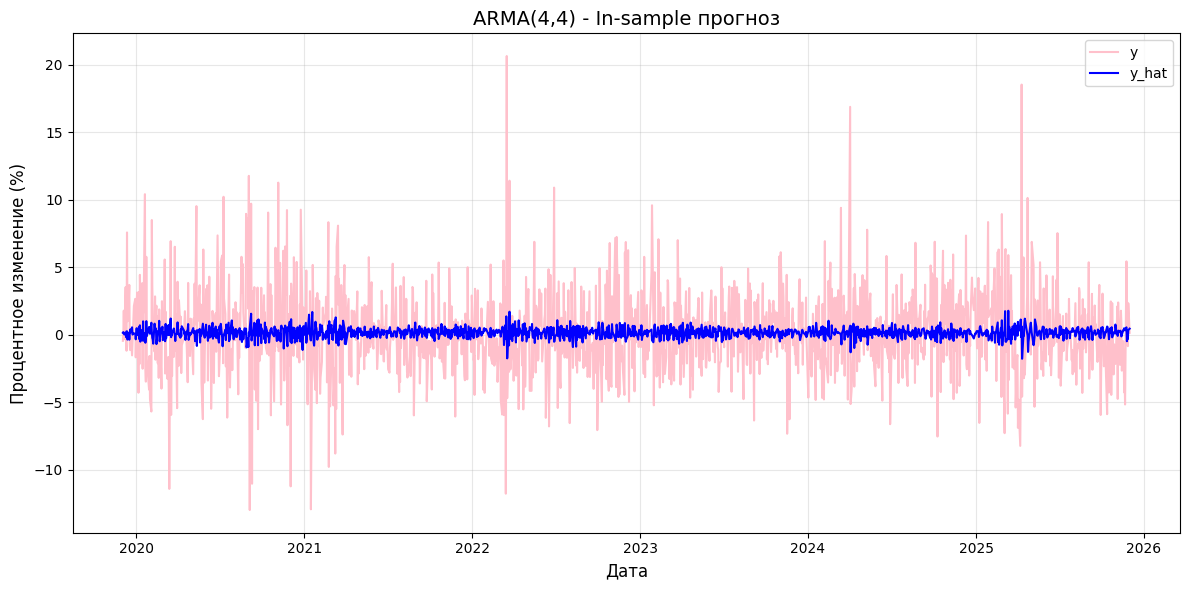

In [70]:
forecast = model.predict()
plt.figure(figsize=(12, 6))
plt.plot(df_prs,color='pink')
plt.plot(forecast,color='blue')
plt.legend(['y','y_hat'])
plt.title("ARMA(4,4) - In-sample прогноз",fontsize=14)
plt.xlabel('Дата', fontsize=12)
plt.ylabel('Процентное изменение (%)', fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

#Прогноз ARMA out of sample

In [71]:
train_size = int(len(df_prs) * 0.8)
train, test = df_prs[:train_size], df_prs[train_size:]

model = ARIMA(train, order=(4,0,4))
model = model.fit()

forecast_size = len(test)

y_hat = model.forecast(steps=forecast_size)
y_hat = pd.DataFrame(y_hat)
y_hat['ds'] = test.index
y_hat = y_hat.set_index('ds')

fig = px.line(title="ARMA(4,4) - out of sample прогноз ")
fig.add_scatter(x=train.index, y=train['pct_change'], mode='lines', name='train', line=dict(color='blue'))
fig.add_scatter(x=test.index, y=test['pct_change'], mode='lines', name='test', line=dict(color='green'))
fig.add_scatter(x=y_hat.index, y=y_hat['predicted_mean'], mode='lines', name='forecast', line=dict(color='red'))


fig.update_layout(template='plotly_white', width=1000, height=500)
fig.update_xaxes(title_text="Дата")
fig.update_yaxes(title_text="процентное изменение")
fig.show()


In [72]:
y_hat.columns = ['pct_change']
btc_forecasted = pd.concat([train, y_hat])
btc_forecasted.head(-10)


,pct_change
ds,
2019-12-03,-0.445930
2019-12-04,0.111974
2019-12-05,1.789718
2019-12-06,-0.329678
2019-12-09,3.528122
...,...
2025-11-11,0.115097
2025-11-12,0.115097
2025-11-13,0.115097


In [73]:
btc_forecasted['y_restored'] = df_mi['y'].iloc[0]
for i in range(1, len(btc_forecasted)):
    btc_forecasted['y_restored'].iloc[i] = btc_forecasted['y_restored'].iloc[i-1] * (1 + btc_forecasted['pct_change'].iloc[i] / 100)
btc_forecasted.head(-10)


,pct_change,y_restored
ds,,
2019-12-03,-0.445930,8.970000
2019-12-04,0.111974,8.980044
2019-12-05,1.789718,9.140762
2019-12-06,-0.329678,9.110627
2019-12-09,3.528122,9.432061
...,...,...
2025-11-11,0.115097,26.961030
2025-11-12,0.115097,26.992061
2025-11-13,0.115097,27.023128


In [74]:
fig = px.line(title="ARMA(4,4) - out of-sample прогноз")
fig.add_scatter(x=df_mi.index[:train_size], y=df_mi['y'][:train_size], mode='lines', name='y(train)', line=dict(color='blue'))
fig.add_scatter(x=df_mi.index[train_size:], y=df_mi['y'][train_size:], mode='lines', name='y(test)', line=dict(color='green'))
fig.add_scatter(x=btc_forecasted.index[train_size:], y=btc_forecasted['y_restored'][train_size:], mode='lines', name='y_predict', line=dict(color='red'))



fig.update_layout(template='plotly_white', width=1100, height=500)
fig.update_xaxes(title_text="Дата")
fig.update_yaxes(title_text="цена на момент открытия")
fig.show()

arma_metric = metrics(df_mi['y'][train_size:],btc_forecasted['y_restored'][train_size-1:])
arma_metric

(23.23, 43.97)

#Прогноз ARIMA in sample

In [75]:
model = auto_arima(df_mi['y'], stepwise=True, trace=True)

print(model.summary())


Performing stepwise search to minimize aic
 ARIMA(2,1,2)(0,0,0)[0] intercept   : AIC=3575.606, Time=3.46 sec
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=3581.882, Time=0.17 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=3582.725, Time=0.10 sec
 ARIMA(0,1,1)(0,0,0)[0] intercept   : AIC=3582.695, Time=0.23 sec
 ARIMA(0,1,0)(0,0,0)[0]             : AIC=3580.948, Time=0.05 sec
 ARIMA(1,1,2)(0,0,0)[0] intercept   : AIC=3585.377, Time=0.84 sec
 ARIMA(2,1,1)(0,0,0)[0] intercept   : AIC=3585.325, Time=0.89 sec
 ARIMA(3,1,2)(0,0,0)[0] intercept   : AIC=3581.664, Time=5.11 sec
 ARIMA(2,1,3)(0,0,0)[0] intercept   : AIC=3581.215, Time=2.55 sec
 ARIMA(1,1,1)(0,0,0)[0] intercept   : AIC=3583.591, Time=0.80 sec
 ARIMA(1,1,3)(0,0,0)[0] intercept   : AIC=3581.040, Time=0.86 sec
 ARIMA(3,1,1)(0,0,0)[0] intercept   : AIC=3581.019, Time=0.75 sec
 ARIMA(3,1,3)(0,0,0)[0] intercept   : AIC=3578.695, Time=4.75 sec
 ARIMA(2,1,2)(0,0,0)[0]             : AIC=3574.755, Time=2.24 sec
 ARIMA(1,1,2)(0,0,0)[0]          

In [76]:
model = ARIMA(df_mi['y'], order=(2,1,2))
model = model.fit()
print(model.summary())


                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                 1476
Model:                 ARIMA(2, 1, 2)   Log Likelihood               -1782.377
Date:                Fri, 05 Dec 2025   AIC                           3574.755
Time:                        07:59:55   BIC                           3601.237
Sample:                             0   HQIC                          3584.628
                               - 1476                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          1.4885      0.015    102.434      0.000       1.460       1.517
ar.L2         -0.9592      0.014    -69.752      0.000      -0.986      -0.932
ma.L1         -1.5145      0.013   -116.099      0.0

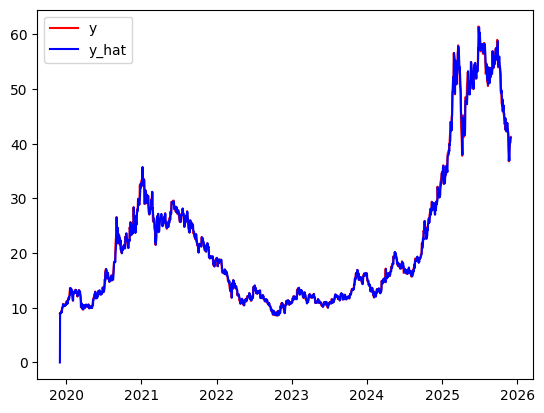

In [77]:
forecast = model.predict()
plt.plot(df_mi['y'],color='red')
plt.plot(forecast,color='blue')
plt.legend(['y','y_hat'])
plt.show()


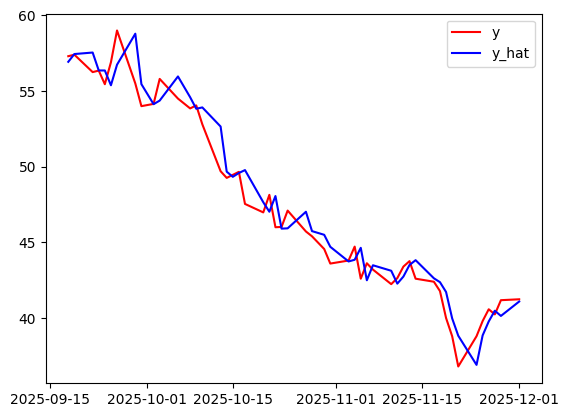

In [78]:
plt.plot(df_mi['y'][-50:],color='red')
plt.plot(forecast[-50:],color='blue')
plt.legend(['y','y_hat'])
plt.show()

#Прогноз ARIMA out of sample

In [79]:
train_size = int(len(df_mi['y']) * 0.7)
train, test = df_mi['y'][:train_size], df_mi['y'][train_size:]
model = auto_arima(train, stepwise=True, trace=True)

print(model.summary())


Performing stepwise search to minimize aic
 ARIMA(2,1,2)(0,0,0)[0] intercept   : AIC=1808.756, Time=1.92 sec
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=1817.764, Time=0.24 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=1815.996, Time=0.11 sec
 ARIMA(0,1,1)(0,0,0)[0] intercept   : AIC=1815.745, Time=0.59 sec
 ARIMA(0,1,0)(0,0,0)[0]             : AIC=1815.799, Time=0.10 sec
 ARIMA(1,1,2)(0,0,0)[0] intercept   : AIC=1818.715, Time=1.84 sec
 ARIMA(2,1,1)(0,0,0)[0] intercept   : AIC=1818.842, Time=0.24 sec
 ARIMA(3,1,2)(0,0,0)[0] intercept   : AIC=inf, Time=2.68 sec
 ARIMA(2,1,3)(0,0,0)[0] intercept   : AIC=1822.551, Time=1.25 sec
 ARIMA(1,1,1)(0,0,0)[0] intercept   : AIC=1817.143, Time=0.49 sec
 ARIMA(1,1,3)(0,0,0)[0] intercept   : AIC=1820.773, Time=0.38 sec
 ARIMA(3,1,1)(0,0,0)[0] intercept   : AIC=1820.840, Time=0.32 sec
 ARIMA(3,1,3)(0,0,0)[0] intercept   : AIC=1812.470, Time=2.85 sec
 ARIMA(2,1,2)(0,0,0)[0]             : AIC=1806.794, Time=0.72 sec
 ARIMA(1,1,2)(0,0,0)[0]             : 

In [80]:
forecast_auto_arima = model.predict(n_periods=len(test))
forecast_auto_arima = pd.DataFrame(forecast_auto_arima)
forecast_auto_arima['ds'] = test.index
forecast_auto_arima.set_index('ds', inplace=True)
forecast_auto_arima.columns = ['y_hat']

forecast_auto_arima


,y_hat
ds,
2024-02-14,12.461590
2024-02-15,12.508455
2024-02-16,12.551659
2024-02-19,12.548818
2024-02-20,12.505501
...,...
2025-11-25,12.507599
2025-11-26,12.507599
2025-11-27,12.507599


In [81]:
fig = px.line(title="Цена Биткоина на момент открытия ARIMA(2,1,2) out of sample прогноз")
fig.add_scatter(x=train.index, y=train, mode='lines', name='train', line=dict(color='blue'))
fig.add_scatter(x=test.index, y=test, mode='lines', name='test', line=dict(color='green'))
fig.add_scatter(x=forecast_auto_arima.index, y=forecast_auto_arima['y_hat'], mode='lines', name='forecast', line=dict(color='red'))


fig.update_layout(template='plotly_white', width=1100, height=800)
fig.update_xaxes(title_text="Дата")
fig.update_yaxes(title_text="цена на момент открытия")
fig.show()

arima_metric_out = metrics(test,forecast_auto_arima['y_hat'])
arima_metric_out

(27.67, 54.09)

#Прогноз ARIMAX in sample с регрессором 1

In [82]:
sony_from_file = pd.read_csv('sony_clean.csv', index_col=0, parse_dates=True)
sony_from_file.columns = ['sony_price']

sony_aligned = sony_from_file.reindex(df_mi.index)
sony_regressor = pd.DataFrame({'sony_price': sony_aligned['sony_price']})

train_reg = sony_regressor.fillna(method='ffill').fillna(method='bfill')


model_sony = auto_arima(df_mi['y'],
                       X=train_reg,
                       stepwise=True,
                       trace=False,
                       suppress_warnings=True
                       )

forecast_sony = model_sony.predict_in_sample(X=train_reg)
forecast_sony = np.asarray(forecast_sony) # Преобразуем в numpy для безопасности

index_full = df_mi.index

forecast_sony_df = pd.DataFrame(
    forecast_sony.reshape(-1, 1),
    index=index_full,
    columns=['y_hat']
)

fig = px.line(title="ARIMAX модель In-Sample предсказания аккций Xiaomi  с регрессором акции Sony")
fig.add_scatter(x=df_mi.index, y=df_mi['y'], mode='lines', name='цена акций Xiaomi', line=dict(color='blue'))
fig.add_scatter(x=forecast_sony_df.index, y=forecast_sony_df['y_hat'], mode='lines',
                name='предсказание с регрессором Sony', line=dict(color='orange'))

fig.update_layout(template='plotly_white', width=1000, height=600)
fig.update_xaxes(title_text="Дата")
fig.update_yaxes(title_text="цена на момент открытия")
fig.show()



#Прогноз ARIMAX out of sample с регрессором 1

In [83]:
sony_from_file = pd.read_csv('sony_clean.csv', index_col=0, parse_dates=True)
sony_from_file.columns = ['sony_price']

sony_aligned = sony_from_file.reindex(df_mi.index, method='ffill')
sony_regressor = pd.DataFrame({'sony_price': sony_aligned['sony_price']})

train_size = int(len(df_mi) * 0.8)
train = df_mi['y'][:train_size]
test = df_mi['y'][train_size:]
train_reg = sony_regressor[:train_size]
test_reg = sony_regressor[train_size:]
forecast_size = len(test)

model_sony = auto_arima(train.values,
                       X=train_reg[['sony_price']].values,
                       stepwise=True,
                       trace=True
                       )

print(model_sony.summary())

forecast_sony = model_sony.predict(n_periods=forecast_size, X=test_reg[['sony_price']].values)
forecast_sony_df = pd.DataFrame(forecast_sony, index=test.index, columns=['y_hat'])
print(forecast_sony_df)

Performing stepwise search to minimize aic
 ARIMA(2,1,2)(0,0,0)[0] intercept   : AIC=1996.424, Time=3.05 sec
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=2007.394, Time=0.18 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=2001.667, Time=0.24 sec
 ARIMA(0,1,1)(0,0,0)[0] intercept   : AIC=2001.085, Time=0.31 sec
 ARIMA(0,1,0)(0,0,0)[0]             : AIC=2005.606, Time=0.24 sec
 ARIMA(1,1,2)(0,0,0)[0] intercept   : AIC=2003.985, Time=1.03 sec
 ARIMA(2,1,1)(0,0,0)[0] intercept   : AIC=2003.921, Time=1.23 sec
 ARIMA(3,1,2)(0,0,0)[0] intercept   : AIC=1992.550, Time=4.37 sec
 ARIMA(3,1,1)(0,0,0)[0] intercept   : AIC=2005.918, Time=0.60 sec
 ARIMA(4,1,2)(0,0,0)[0] intercept   : AIC=1989.564, Time=4.37 sec
 ARIMA(4,1,1)(0,0,0)[0] intercept   : AIC=2007.266, Time=1.30 sec
 ARIMA(5,1,2)(0,0,0)[0] intercept   : AIC=2010.570, Time=2.15 sec
 ARIMA(4,1,3)(0,0,0)[0] intercept   : AIC=2001.398, Time=5.06 sec
 ARIMA(3,1,3)(0,0,0)[0] intercept   : AIC=2002.275, Time=3.63 sec
 ARIMA(5,1,1)(0,0,0)[0] intercept

In [84]:
fig = px.line(title="ARIMAX Out of sample прогноз  стоимости акций Xiaomi с непрерывным регрессором акции Sony ")
fig.add_scatter(x=train.index, y=train, mode='lines', name='Train', line=dict(color='blue'))
fig.add_scatter(x=test.index, y=test, mode='lines', name='Test', line=dict(color='green'))

fig.add_scatter(x=forecast_sony_df.index, y=forecast_sony_df['y_hat'], mode='lines',
                name='С регрессором акции Sony', line=dict(color='orange'))

fig.update_layout(template='plotly_white', width=1100, height=800)
fig.update_xaxes(title_text="Дата")
fig.update_yaxes(title_text="Цена на момент открытия ")
fig.show()

fig = go.Figure()

fig.add_trace(go.Scatter(
    x=df_mi.index,
    y=df_mi['y'],
    mode='lines',
    name='Цена Xiaomi',
    line=dict(color='orange'),
    yaxis='y1'
))

fig.add_trace(go.Scatter(
    x=sony_from_file.index,
    y=sony_from_file['sony_price'],
    mode='lines',
    name='Цена  Sony ',
    line=dict(color='green'),
    yaxis='y2'
))

fig.update_layout(
    title="Цены Xiaomi и Sony",
    template='plotly_white',
    width=1000,
    height=500,
    yaxis=dict(
        title='Цена Xiaomi (USDT)',
        titlefont=dict(color='orange'),
        tickfont=dict(color='orange')
    ),
    yaxis2=dict(
        title='Цена Sony (USDT)',
        titlefont=dict(color='green'),
        tickfont=dict(color='green'),
        overlaying='y',
        side='right'
    ),
    xaxis=dict(title='Date')
)

fig.show()

#Прогноз ARIMAX in sample с регрессором 2

In [85]:
apple_from_file = pd.read_csv('apple_open_price_clean.csv', index_col=0, parse_dates=True)
apple_from_file.columns = ['apple_price']

apple_aligned = apple_from_file.reindex(df_mi.index)
apple_regressor = pd.DataFrame({'apple_price': apple_aligned['apple_price']})

train_reg = apple_regressor.fillna(method='ffill').fillna(method='bfill')


model_apple = auto_arima(df_mi['y'],
                       X=train_reg,
                       stepwise=True,
                       trace=False,
                       suppress_warnings=True
                       )

forecast_apple = model_apple.predict_in_sample(X=train_reg)
forecast_apple = np.asarray(forecast_apple) # Преобразуем в numpy для безопасности

index_full = df_mi.index

forecast_apple_df = pd.DataFrame(
    forecast_apple.reshape(-1, 1),
    index=index_full,
    columns=['y_hat']
)

fig = px.line(title="ARIMAX модель In-Sample предсказания аккций Xiaomi  с регрессором акции Apple")
fig.add_scatter(x=df_mi.index, y=df_mi['y'], mode='lines', name='цена акций Xiaomi', line=dict(color='blue'))
fig.add_scatter(x=forecast_apple_df.index, y=forecast_apple_df['y_hat'], mode='lines',
                name='предсказание с регрессором Apple', line=dict(color='orange'))

fig.update_layout(template='plotly_white', width=1000, height=600)
fig.update_xaxes(title_text="Дата")
fig.update_yaxes(title_text="цена на момент открытия")
fig.show()

#Прогноз ARIMAX out of sample с регрессором 2

In [86]:
apple_from_file = pd.read_csv('apple_open_price_clean.csv', index_col=0, parse_dates=True)
apple_from_file.columns = ['apple_price']

apple_aligned = apple_from_file.reindex(df_mi.index, method='ffill')
apple_regressor = pd.DataFrame({'apple_price': apple_aligned['apple_price']})

train_size = int(len(df_mi) * 0.8)
train = df_mi['y'][:train_size]
test = df_mi['y'][train_size:]
train_reg = apple_regressor[:train_size]
test_reg = apple_regressor[train_size:]
forecast_size = len(test)

model_apple = auto_arima(train.values,
                       X=train_reg[['apple_price']].values,
                       stepwise=True,
                       trace=True
                       )

print(model_apple.summary())

forecast_apple = model_apple.predict(n_periods=forecast_size, X=test_reg[['apple_price']].values)
forecast_apple_df = pd.DataFrame(forecast_apple, index=test.index, columns=['y_hat'])
print(forecast_apple_df)

Performing stepwise search to minimize aic
 ARIMA(2,1,2)(0,0,0)[0] intercept   : AIC=2000.441, Time=1.96 sec
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=2012.935, Time=0.18 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=2006.969, Time=0.26 sec
 ARIMA(0,1,1)(0,0,0)[0] intercept   : AIC=2006.273, Time=0.35 sec
 ARIMA(0,1,0)(0,0,0)[0]             : AIC=2011.077, Time=0.28 sec
 ARIMA(1,1,2)(0,0,0)[0] intercept   : AIC=2008.770, Time=1.34 sec
 ARIMA(2,1,1)(0,0,0)[0] intercept   : AIC=2008.701, Time=0.63 sec
 ARIMA(3,1,2)(0,0,0)[0] intercept   : AIC=2012.519, Time=4.00 sec
 ARIMA(2,1,3)(0,0,0)[0] intercept   : AIC=2012.460, Time=2.14 sec
 ARIMA(1,1,1)(0,0,0)[0] intercept   : AIC=2007.293, Time=0.92 sec
 ARIMA(1,1,3)(0,0,0)[0] intercept   : AIC=2010.491, Time=1.96 sec
 ARIMA(3,1,1)(0,0,0)[0] intercept   : AIC=2010.697, Time=0.54 sec
 ARIMA(3,1,3)(0,0,0)[0] intercept   : AIC=2005.369, Time=4.96 sec
 ARIMA(2,1,2)(0,0,0)[0]             : AIC=1998.576, Time=2.14 sec
 ARIMA(1,1,2)(0,0,0)[0]          

In [87]:
fig = px.line(title="ARIMAX Out of sample прогноз  стоимости акций Xiaomi с непрерывным регрессором акции Аpple ")
fig.add_scatter(x=train.index, y=train, mode='lines', name='Train', line=dict(color='blue'))
fig.add_scatter(x=test.index, y=test, mode='lines', name='Test', line=dict(color='green'))

fig.add_scatter(x=forecast_apple_df.index, y=forecast_apple_df['y_hat'], mode='lines',
                name='С регрессором акции Аpple', line=dict(color='orange'))

fig.update_layout(template='plotly_white', width=1100, height=800)
fig.update_xaxes(title_text="Дата")
fig.update_yaxes(title_text="Цена на момент открытия ")
fig.show()

fig = go.Figure()
fig.add_trace(go.Scatter(
    x=df_mi.index,
    y=df_mi['y'],
    mode='lines',
    name='Цена Xiaomi',
    line=dict(color='orange'),
    yaxis='y1'
))

fig.add_trace(go.Scatter(
    x=apple_from_file.index,
    y=apple_from_file['apple_price'],
    mode='lines',
    name='Цена  Apple ',
    line=dict(color='green'),
    yaxis='y2'
))

fig.update_layout(
    title="Цены Xiaomi и Apple",
    template='plotly_white',
    width=1000,
    height=500,
    yaxis=dict(
        title='Цена Xiaomi (USDT)',
        titlefont=dict(color='orange'),
        tickfont=dict(color='orange')
    ),
    yaxis2=dict(
        title='Цена Apple (USDT)',
        titlefont=dict(color='green'),
        tickfont=dict(color='green'),
        overlaying='y',
        side='right'
    ),
    xaxis=dict(title='Date')
)

fig.show()